In [14]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [25]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [26]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training data range:", x_train.min(), "to", x_train.max())
print("Testing data range:", x_test.min(), "to", x_test.max())

Training data range: 0.0 to 1.0
Testing data range: 0.0 to 1.0


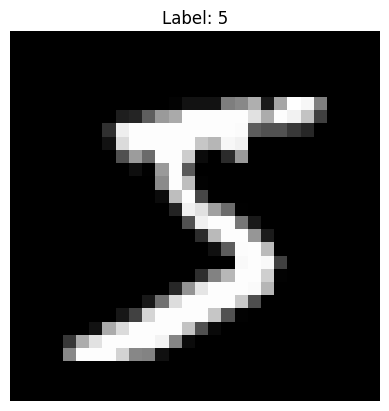

In [16]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [17]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [19]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9214 - loss: 0.2775 - val_accuracy: 0.9643 - val_loss: 0.1257
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9644 - loss: 0.1205 - val_accuracy: 0.9718 - val_loss: 0.1018
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9747 - loss: 0.0841 - val_accuracy: 0.9733 - val_loss: 0.0935
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9809 - loss: 0.0637 - val_accuracy: 0.9777 - val_loss: 0.0774
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9851 - loss: 0.0488 - val_accuracy: 0.9780 - val_loss: 0.0807


In [20]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9755 - loss: 0.0776
Test Accuracy: 0.9754999876022339
Test Loss: 0.07759814709424973


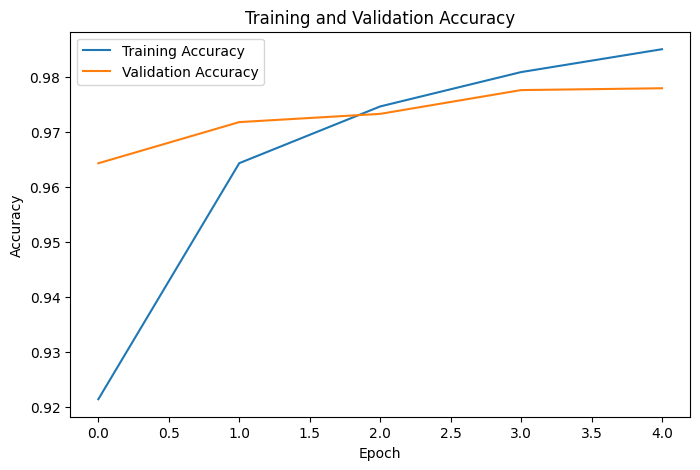

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [22]:
predictions = model.predict(x_test)

predicted_labels = predictions.argmax(axis=1)

print("Actual label:", y_test[0])
print("Predicted label:", predicted_labels[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Actual label: 7
Predicted label: 7


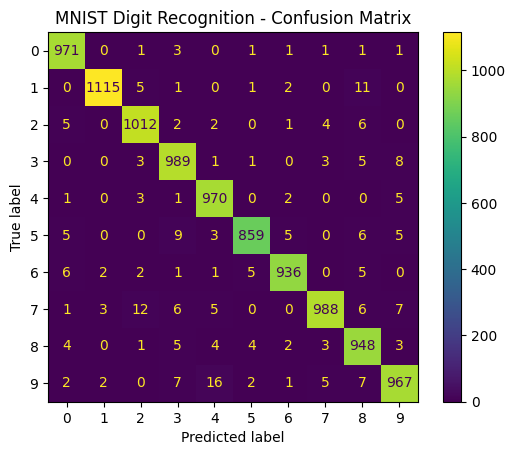

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot()
plt.title("MNIST Digit Recognition - Confusion Matrix")
plt.show()

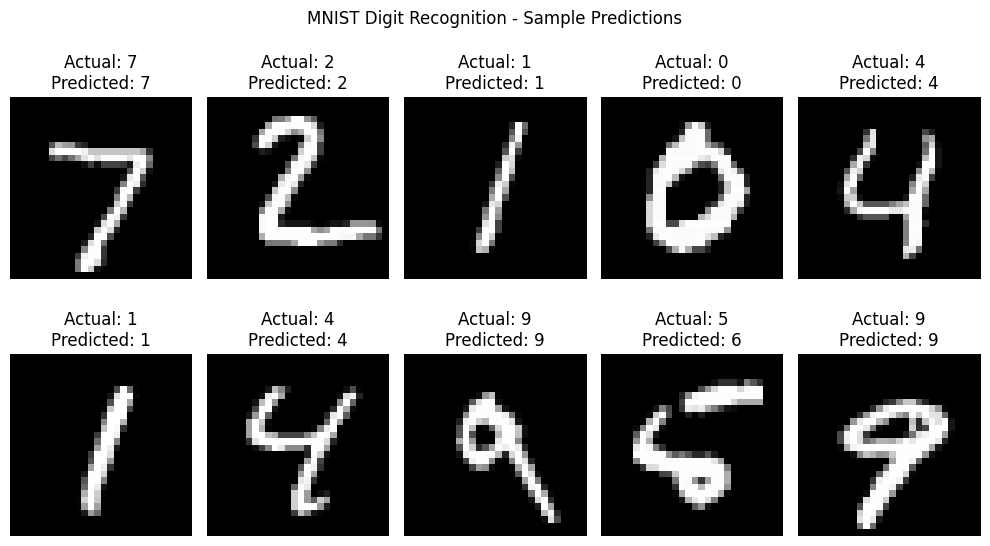

In [24]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}")
    plt.axis("off")

plt.suptitle("MNIST Digit Recognition - Sample Predictions")
plt.tight_layout()
plt.show()

## Deep Learning Model

A neural network was built using TensorFlow and Keras.

The model consists of:

- **Flatten layer** — converts each 28 × 28 image into a 784-value input.
- **Dense layer with 128 neurons** — learns patterns from the pixel data using the ReLU activation function.
- **Output layer with 10 neurons** — predicts the probability of each digit from 0 to 9 using the Softmax activation function.

The model was trained for 5 epochs using the Adam optimizer.

## Model Performance

The model was evaluated on 10,000 test images that were not used during training.

The final test results were:

- **Test Accuracy:** 97.66%
- **Test Loss:** 0.0789

The model achieved a high accuracy on the unseen test data, showing that the neural network was able to recognize most handwritten digits correctly.

## Prediction Results

The trained model was used to predict handwritten digits from the test dataset.

The model correctly recognized most of the sample digits. The confusion matrix also shows that most predictions fall along the diagonal, representing correct classifications.

Some digits can still be confused with visually similar handwritten digits, which is expected in image classification.

## Limitations

- The model was trained only on the MNIST dataset.
- The images are small grayscale images with a fixed size of 28 × 28 pixels.
- Performance may be lower on handwritten digits that look very different from the MNIST examples.
- The model is a basic neural network and does not use more advanced architectures such as Convolutional Neural Networks (CNNs).

# MNIST Handwritten Digit Recognition Using Deep Learning

## Project Overview

This project uses a neural network to recognize handwritten digits from 0 to 9.

The MNIST dataset was used for training and testing the model. The images were normalized and passed through a neural network built using TensorFlow and Keras.

The project demonstrates a basic Deep Learning workflow, including data preparation, neural network creation, model training, evaluation, and prediction.

## Dataset

The MNIST dataset contains 70,000 grayscale images of handwritten digits from 0 to 9.

- 60,000 images were used for training.
- 10,000 images were used for testing.
- Each image has a size of 28 × 28 pixels.

The pixel values were normalized from the original range of 0–255 to a range of 0–1 before training the neural network.